# Partie I : Nettoyage et Préparation des Données

Le fichier `vgsales.csv` contient les ventes de jeux vidéo, en millions d'exemplaires, selon la plateforme et la région. Avant d'analyser ces ventes, on met le fichier au propre : structure, valeurs manquantes, types et doublons.

## 1. Charger et examiner la structure du dataset

In [36]:
import pandas as pd

df = pd.read_csv("BDD_states/vgsales.csv")

print("Nombre de lignes et de colonnes :", df.shape)
df.head(10)

Nombre de lignes et de colonnes : (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [38]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Le dataset contient **16 598 jeux** et **11 colonnes**.

- `Rank` : classement du jeu selon les ventes mondiales
- `Name` : titre du jeu
- `Platform` : console
- `Year` : année de sortie
- `Genre` : genre
- `Publisher` : éditeur
- `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales` : ventes en millions d'exemplaires

`Rank` est un entier et les ventes sont des décimaux, ce qui est cohérent. `Year` est en float (`2006.0`) : on verra que cela vient des valeurs manquantes. Les quatre autres colonnes sont du texte.

## 2. Identifier et traiter les valeurs manquantes

In [39]:
manquantes = df.isna().sum()
pourcentage = (df.isna().mean() * 100).round(2)

bilan = pd.DataFrame({
    "Valeurs manquantes": manquantes,
    "Pourcentage (%)": pourcentage
})

bilan[bilan["Valeurs manquantes"] > 0]

,Valeurs manquantes,Pourcentage (%)
Year,271,1.63
Publisher,58,0.35


Deux colonnes sont incomplètes :

- `Year` : 271 valeurs, soit 1,63 % des lignes
- `Publisher` : 58 valeurs, soit 0,35 % des lignes

Pour l'éditeur, on remplace le vide par `Inconnu`. Il y a peu de cas, et on conserve les ventes de ces jeux.

Pour l'année, on supprime les lignes. On ne peut pas la retrouver de façon fiable avec les autres colonnes, et elle servira à suivre les ventes dans le temps. La perte reste limitée, moins de 2 % du fichier.

In [40]:
df["Publisher"] = df["Publisher"].fillna("Inconnu")
df = df.dropna(subset=["Year"]).copy()

print("Lignes restantes :", len(df))
df.isna().sum()

Lignes restantes : 16327


Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

## 3. Vérifier et corriger les types de données

`Year` était en float à cause des valeurs manquantes. Une fois la colonne complète, on la passe en entier.

On retire aussi les espaces en début et en fin de texte, pour éviter qu'un même nom soit compté deux fois à cause d'un espace.

In [41]:
df["Year"] = df["Year"].astype(int)

colonnes_texte = ["Name", "Platform", "Genre", "Publisher"]
for col in colonnes_texte:
    df[col] = df[col].str.strip()

df.dtypes

Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

## 4. Détecter et supprimer les doublons

In [42]:
print("Doublons exacts :", df.duplicated().sum())

cles = ["Name", "Platform", "Year"]
print("Doublons sur nom + plateforme + année :", df.duplicated(subset=cles).sum())

df[df.duplicated(subset=cles, keep=False)].sort_values(cles)

Doublons exacts : 0
Doublons sur nom + plateforme + année : 1


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
603,604,Madden NFL 13,PS3,2012,Sports,Electronic Arts,2.11,0.23,0.0,0.22,2.56
16127,16130,Madden NFL 13,PS3,2012,Sports,Electronic Arts,0.00,0.01,0.0,0.00,0.01


Aucune ligne n'est recopiée à l'identique. En revanche, *Madden NFL 13* sur PS3 en 2012 est présent deux fois : une ligne à 2,56 millions de ventes, et une autre à 0,01 million.

On retient qu'un jeu correspond à un triplet nom, plateforme et année. On garde la première ligne, celle du classement d'origine, qui porte les ventes les plus élevées.

In [43]:
avant = len(df)
df = df.drop_duplicates(subset=["Name", "Platform", "Year"], keep="first").copy()

print("Lignes supprimées :", avant - len(df))
print("Doublons restants :", df.duplicated(subset=["Name", "Platform", "Year"]).sum())

Lignes supprimées : 1
Doublons restants : 0


## 5. Préparer le dataset pour l'analyse

Le rang d'origine n'est plus continu après les suppressions (le fichier allait jusqu'au rang 16 600). On retrie les jeux par ventes mondiales et on recalcule `Rank`.

On contrôle aussi les années récentes. Le fichier est surtout renseigné jusqu'en 2016 : au-delà, il ne reste que quelques titres. On les retire pour ne pas fausser une analyse par année.

In [44]:
print(df["Year"].value_counts().sort_index().tail(8))

df = df[df["Year"] <= 2016].copy()
df = df.sort_values("Global_Sales", ascending=False).reset_index(drop=True)
df.drop(columns=["Rank"], inplace=True)
df.to_csv("BDD_states/vgsales_clean.csv", index=False)

print("Dimensions finales :", df.shape)
print("Années :", df["Year"].min(), "->", df["Year"].max())
df.head()

Year
2011    1139
2012     656
2013     546
2014     582
2015     614
2016     344
2017       3
2020       1
Name: count, dtype: int64
Dimensions finales : (16322, 10)
Années : 1980 -> 2016


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16322 entries, 0 to 16321
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16322 non-null  object 
 1   Platform      16322 non-null  object 
 2   Year          16322 non-null  int64  
 3   Genre         16322 non-null  object 
 4   Publisher     16322 non-null  object 
 5   NA_Sales      16322 non-null  float64
 6   EU_Sales      16322 non-null  float64
 7   JP_Sales      16322 non-null  float64
 8   Other_Sales   16322 non-null  float64
 9   Global_Sales  16322 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.2+ MB


Le fichier nettoyé est enregistré dans `vgsales_clean.csv`.

Il contient **16 322 jeux**, sortis entre **1980 et 2016** :

- les éditeurs manquants sont codés `Inconnu`
- les jeux sans année ont été retirés
- `Year` est un entier
- chaque couple jeu / plateforme / année n'apparaît qu'une fois
- `Rank` suit de nouveau l'ordre des ventes mondiales

Le dataset est prêt pour l'analyse.

# Partie II : Analyse Exploratoire (EDA)

## A. Statistiques descriptives



### Résumer les variables numériques.



In [47]:
df.head(1)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74


In [48]:
df.describe()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16322.000000,16322.000000,16322.000000,16322.000000,16322.000000,16322.000000
mean,2006.403321,0.265480,0.147599,0.078682,0.048339,0.540376
std,5.826968,0.821706,0.508837,0.311602,0.189913,1.565949
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,2016.000000,41.490000,29.020000,10.220000,10.570000,82.740000


***Interprétation des variables numériques***

Les variables numériques comptent chacune **16 322 observations**. Les années s'étendent de **1980 à 2016** ; la médiane est **2007** et la moyenne **2006,4**, ce qui situe la majorité des données autour des années 2000.

Les ventes moyennes par jeu sont les plus élevées en **Amérique du Nord** (**0,265 million**), suivies de l'**Europe** (**0,148 million**), du **Japon** (**0,079 million**) et des **autres régions** (**0,048 million**). Les ventes mondiales moyennes atteignent **0,540 million** par jeu.

Pour toutes les variables de ventes, la moyenne dépasse nettement la médiane (par exemple **0,540** contre **0,170 million** à l'échelle mondiale) et les valeurs maximales sont très supérieures aux 75e percentiles. Cela indique une distribution fortement asymétrique : la plupart des jeux se vendent relativement peu, tandis que quelques grands succès tirent la moyenne vers le haut. Le maximum mondial est de **82,74 millions**.

En résumé, les ventes sont très inégales d'un jeu à l'autre et l'Amérique du Nord constitue le marché régional moyen le plus important. Les moyennes des ventes régionales totalisent environ **0,541 million**, valeur proche de la moyenne mondiale (**0,540 million**) ; le faible écart peut venir des arrondis.

### Identifier les 10 jeux les plus vendus.



In [52]:
top_10 = df.nlargest(10, "Global_Sales")[["Name", "Platform", "Year", "Global_Sales"]].reset_index(drop=True)

In [53]:
top_10

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.82
3,Wii Sports Resort,Wii,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,Wii,2006,29.02
8,New Super Mario Bros. Wii,Wii,2009,28.62
9,Duck Hunt,NES,1984,28.31


***Interprétation du classement des 10 jeux les plus vendus***

Le classement est établi selon les ventes mondiales (`Global_Sales`), exprimées en millions d'exemplaires. **Wii Sports** arrive largement en tête avec **82,74 millions**, soit plus du double du deuxième, **Super Mario Bros.** (**40,24 millions**). **Mario Kart Wii** complète le podium avec **35,82 millions**.

Les dix titres du classement sont :

1. *Wii Sports* : Wii, 2006 : **82,74 millions**
2. *Super Mario Bros.* : NES, 1985 : **40,24 millions**
3. *Mario Kart Wii* : Wii, 2008 : **35,82 millions**
4. *Wii Sports Resort* : Wii, 2009 : **33,00 millions**
5. *Pokémon Red/Pokémon Blue* : Game Boy, 1996 : **31,37 millions**
6. *Tetris* : Game Boy, 1989 : **30,26 millions**
7. *New Super Mario Bros.* : DS, 2006 : **30,01 millions**
8. *Wii Play* : Wii, 2006 : **29,02 millions**
9. *New Super Mario Bros. Wii* : Wii, 2009 : **28,62 millions**
10. *Duck Hunt* : NES, 1984 : **28,31 millions**

La plateforme Wii est particulièrement représentée, avec **cinq jeux sur dix**. Le classement comprend aussi des titres NES et Game Boy, ainsi qu'un jeu DS : les grands succès couvrent donc plusieurs générations de consoles, de **1984 à 2009**. Les ventes de *Wii Sports* se distinguent nettement, tandis que les jeux classés de la 2e à la 10e place affichent des chiffres plus rapprochés, entre **28,31 et 40,24 millions**.

## B. Tendances temporelles

### Jeux sortis par année.



<Axes: title={'center': 'Nombre de jeux recensés par année'}, xlabel='Année', ylabel='Nombre de jeux recensés'>

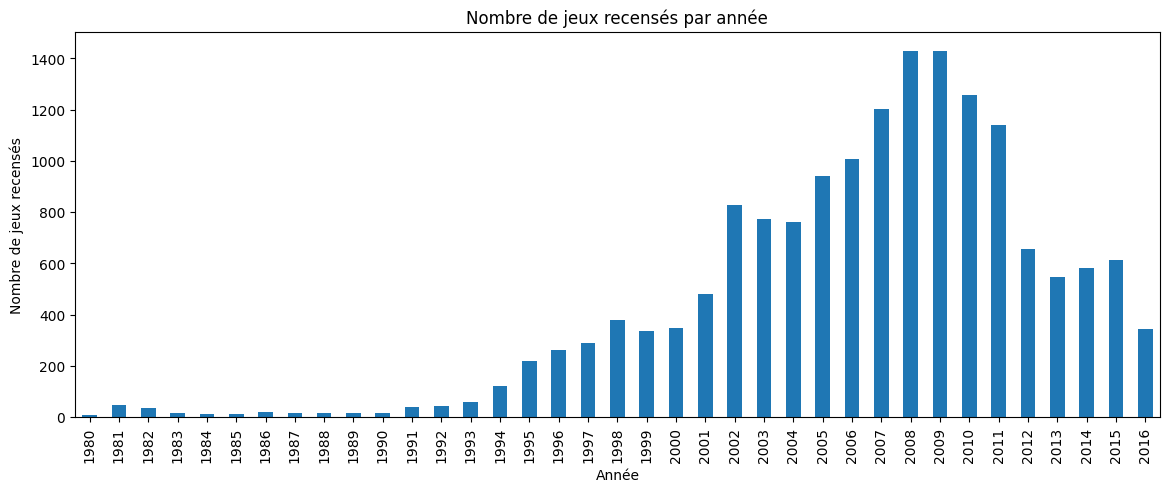

In [54]:
jeux_par_annee = df.dropna(subset=["Year"]).groupby("Year").size()

jeux_par_annee.plot(
    kind="bar",
    figsize=(14, 5),
    xlabel="Année",
    ylabel="Nombre de jeux recensés",
    title="Nombre de jeux recensés par année"
)

***Interprétation du nombre de jeux recensés par année***

Le nombre d'entrées recensées augmente fortement à partir du milieu des années 1990 et atteint un maximum en **2008 et 2009**, avec environ **1 430 jeux** par année. Après ce pic, le nombre diminue : la baisse devient particulièrement marquée à partir de **2012**. Les années les plus anciennes, notamment les années 1980, comptent peu d'entrées dans ce jeu de données.

Cette évolution décrit les jeux présents dans le dataset, et non nécessairement le nombre réel de jeux publiés chaque année. Comme un même titre peut apparaître sur plusieurs plateformes, le comptage des lignes peut aussi compter plusieurs fois ce titre. Enfin, les chiffres faibles des années récentes  en particulier **2016**  peuvent être liés à des données incomplètes.

### Evolution des ventes mondiales

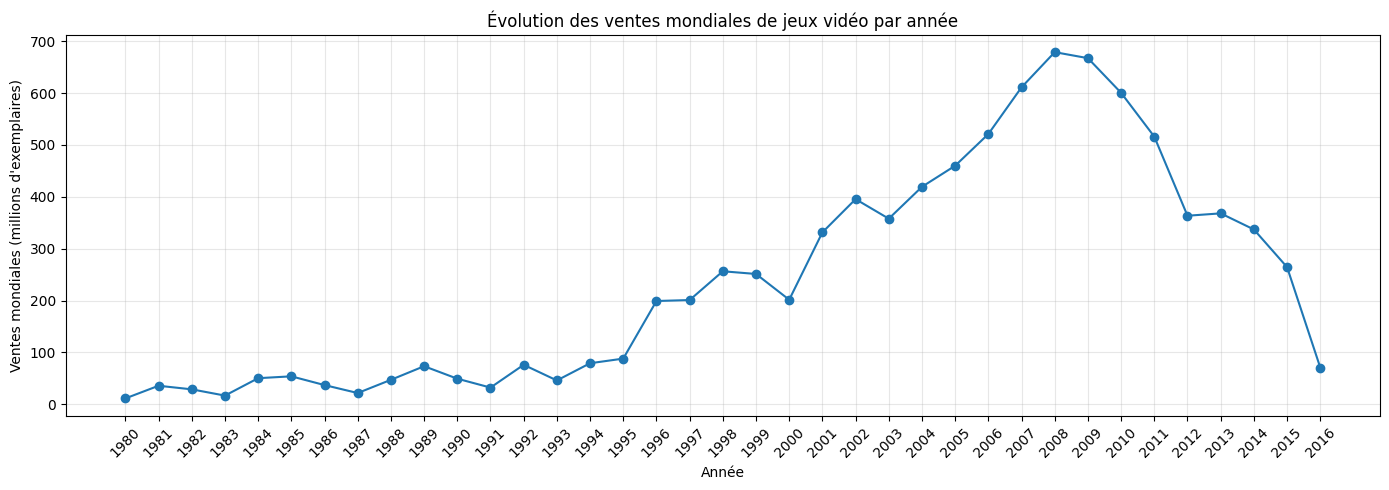

In [55]:
import matplotlib.pyplot as plt

ventes_mondiales_par_annee = (
    df.groupby("Year")["Global_Sales"]
    .sum()
    .sort_index()
)

ax = ventes_mondiales_par_annee.plot(
    kind="line",
    marker="o",
    figsize=(14, 5),
    title="Évolution des ventes mondiales de jeux vidéo par année"
)
ax.set_xlabel("Année")
ax.set_ylabel("Ventes mondiales (millions d'exemplaires)")
ax.grid(True, alpha=0.3)
plt.xticks(ventes_mondiales_par_annee.index, rotation=45)
plt.tight_layout()
plt.show()

***Interprétation***

Les ventes mondiales cumulées augmentent progressivement au début de la période, puis connaissent une forte hausse à partir des années 2000. Elles atteignent leur niveau le plus élevé vers la fin des années 2000, avant de diminuer au cours des années suivantes. Cette évolution suit en partie le nombre de jeux recensés par année : davantage de titres présents dans le dataset peut contribuer à un total de ventes plus important.

Les valeurs des premières années et de **2016** sont à interpréter avec prudence : le catalogue recensé est plus réduit et les données de fin de période peuvent être incomplètes. Le graphique représente la somme des ventes mondiales des entrées du dataset pour chaque année.

(ces 2 dernières questions sont très proches, et on peut les combiner pour une interprétation globale des tendances temporelles)

## C. Analyse des genres

### Fréquence des genres.



In [56]:
df.head(1)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74


<Axes: title={'center': 'Fréquence des genres de jeux vidéo'}, xlabel='Genre'>

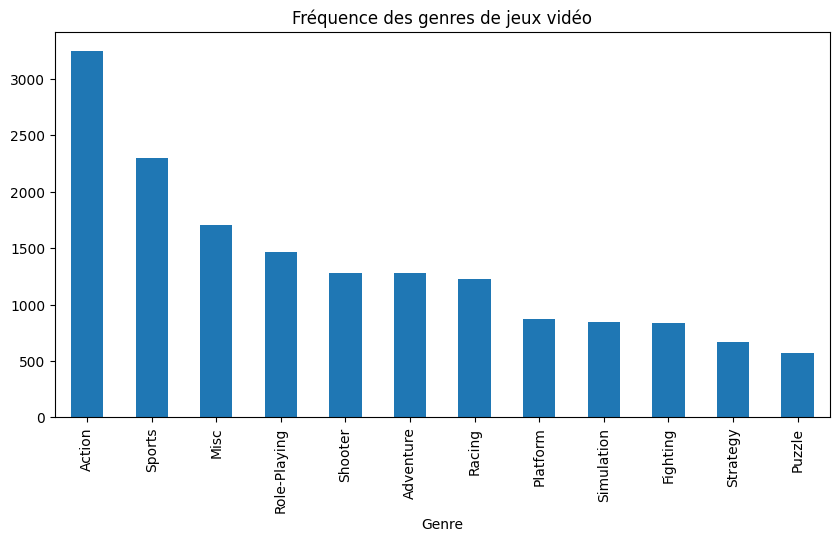

In [60]:
df["Genre"].value_counts().plot(kind="bar", figsize=(10, 5), title="Fréquence des genres de jeux vidéo")

***Interprétation de la fréquence des genres***

Le genre **Action** est le plus représenté dans le dataset, avec un peu plus de **3 200 entrées**, soit environ un cinquième des jeux recensés. Il est suivi par **Sports** (environ **2 300**) et **Misc** (près de **1 700**). Les genres **Role-Playing**, **Shooter**, **Adventure** et **Racing** sont également bien représentés, avec environ **1 200 à 1 500 entrées** chacun.

À l'inverse, **Puzzle** et **Strategy** sont les genres les moins fréquents, avec environ **600 à 700 entrées**. La distribution est donc déséquilibrée : le catalogue contient beaucoup plus de jeux d'action que de jeux de réflexion ou de stratégie. Ces effectifs comptent les entrées du dataset par jeu et plateforme, et non nécessairement les titres uniques.

### Ventes par genre.



,Ventes mondiales (millions)
Genre,
Action,1722.87
Sports,1309.23
Shooter,1026.20
Role-Playing,923.80
Platform,829.15
Misc,797.62
Racing,726.77
Fighting,444.05
Simulation,389.87


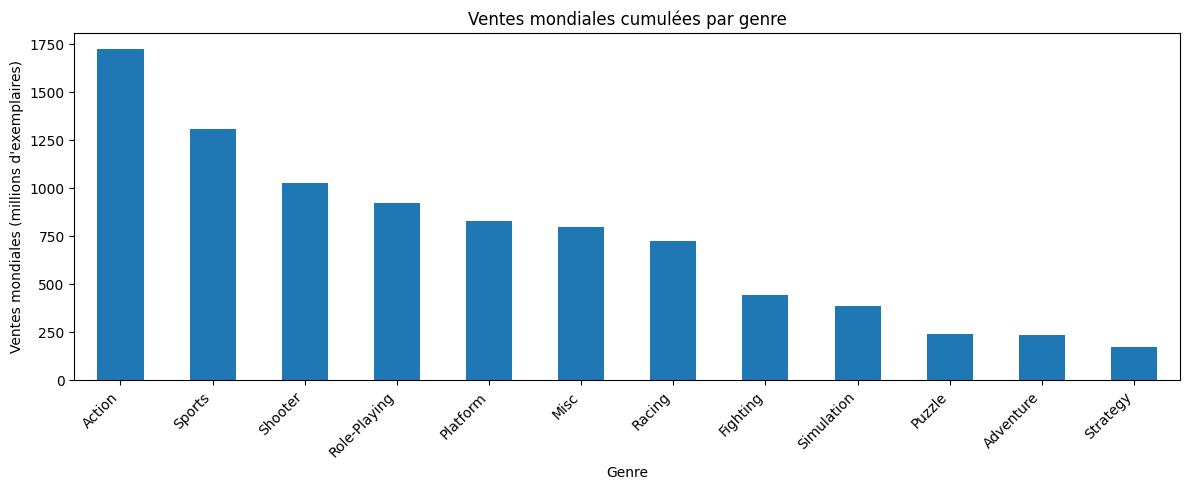

In [61]:
ventes_par_genre = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(ventes_par_genre.rename("Ventes mondiales (millions)").to_frame())

ax = ventes_par_genre.plot(
    kind="bar",
    figsize=(12, 5),
    title="Ventes mondiales cumulées par genre"
)
ax.set_xlabel("Genre")
ax.set_ylabel("Ventes mondiales (millions d'exemplaires)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

***Interprétation des ventes par genre***

Le genre **Action** arrive en tête avec **1 722,87 millions** d'exemplaires vendus dans le monde. Il est suivi par **Sports** (**1 309,23 millions**) et **Shooter** (**1 026,20 millions**). À l'autre extrémité, **Strategy** totalise le moins de ventes (**173,43 millions**), derrière **Adventure** (**234,80 millions**) et **Puzzle** (**242,22 millions**). Les ventes cumulées d'Action sont ainsi près de dix fois supérieures à celles de Strategy.

Contrairement au graphique de fréquence, cette comparaison porte sur le volume vendu et non sur le nombre de jeux recensés : un genre fréquent n'est donc pas nécessairement celui qui réalise le plus de ventes. Les ventes sont additionnées à partir des lignes du dataset, qui correspondent à des jeux sur des plateformes données.